# Part 1 – Understanding the Problem & Dataset

## Step 1 - Load Dataset

In [29]:
import pandas as pd

# Load dataset (make sure loan_data.csv is in your working folder)
df = pd.read_csv("/Users/guillaume/Library/CloudStorage/OneDrive-DeVinci/A5/S1/Machine Learning Avancé/DAY2/TP1/loan_data.csv")

# First look at the dataset
df.head()


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


Question for students: What do you notice about the columns? Which look numerical? Which are categorical?

The columns look logical. Age, income and loan information such as credit score are numerical while gender, level of education and the intent of the loan are categorical.


## Step 2 – Dataset structure

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

Question: How many rows and columns? Are there missing values?

There are 14 columns and 45000 rows, there are no missing values.


## Step 3 – Target distribution

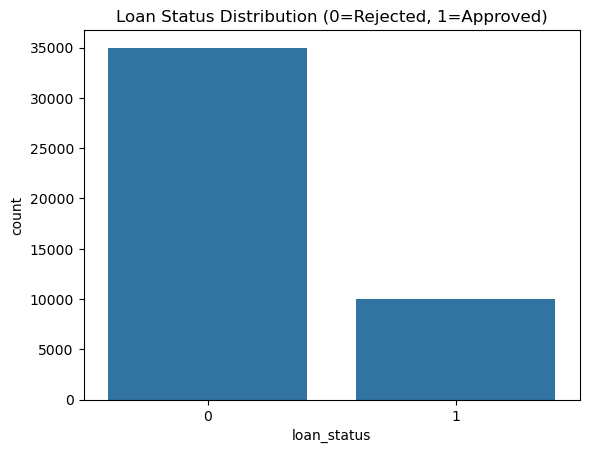

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="loan_status", data=df)
plt.title("Loan Status Distribution (0=Rejected, 1=Approved)")
plt.show()


Question: Is the dataset balanced (equal approved/rejected)? Why does it matter?

The dataset is unequal. There are more rejected (35000) than approved (10000) loans. It is important in understanding why loans are rejected as many reasons could mean a client does not repay. It is also because more loans are rejected than approved.
It also matters because the algorithm might learn only to refuse loans as it was trained only on rejected loans.

## Step 4 – Gender distribution

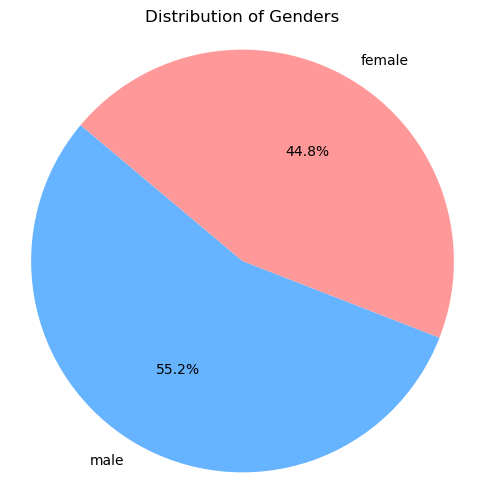

In [32]:
gender_counts = df['person_gender'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', 
        startangle=140, colors=['#66b3ff','#ff9999'])
plt.title("Distribution of Genders")
plt.axis("equal")
plt.show()


Question: Do you think gender should affect loan approval? Why might using gender be problematic?

Gender should not impact loan approval. Using gender can be problematic in regard of the law and of moral and ethics.

## Step 5 – Credit score distribution


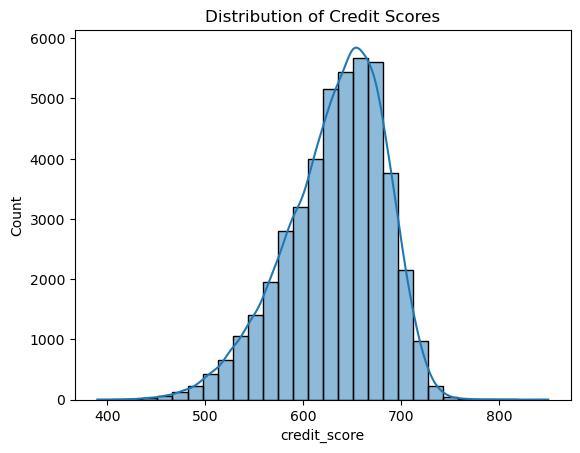

In [33]:
sns.histplot(df['credit_score'], bins=30, kde=True)
plt.title("Distribution of Credit Scores")
plt.show()


Question: What do you expect: will high credit scores increase or decrease loan approval probability?

I expect that a high credit score wille increase loan approval probabilty as it means the person has a better credit history (no financial problems in the past).

## 🔎 Step 6 – Loan amount vs approval


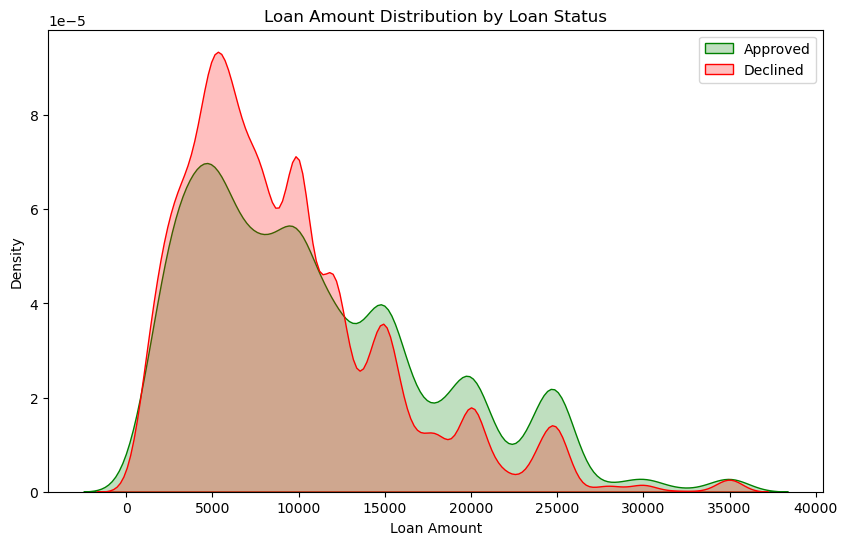

In [34]:
plt.figure(figsize=(10,6))
sns.kdeplot(data=df[df['loan_status']==1], x='loan_amnt', label='Approved',
            fill=True, color='green')
sns.kdeplot(data=df[df['loan_status']==0], x='loan_amnt', label='Declined',
            fill=True, color='red')
plt.title("Loan Amount Distribution by Loan Status")
plt.xlabel("Loan Amount")
plt.ylabel("Density")
plt.legend()
plt.show()


Question: Do bigger loans tend to be riskier? What does the plot show?

The plot shows that bigger loans (12500-33000) tend to be safer as they are approved more. Smaller loans tend to be riskier.

## Step 7 – Correlation analysis


loan_status                       1.000000
loan_percent_income               0.384880
loan_int_rate                     0.332005
person_home_ownership_RENT        0.255239
loan_amnt                         0.107714
loan_intent_MEDICAL               0.065195
loan_intent_HOMEIMPROVEMENT       0.033838
person_home_ownership_OTHER       0.013645
person_education_Bachelor         0.004728
person_education_Doctorate        0.001833
person_education_High School      0.001277
person_gender                    -0.000561
person_education_Master          -0.004741
credit_score                     -0.007647
cb_person_cred_hist_length       -0.014851
person_emp_exp                   -0.020481
person_age                       -0.021476
loan_intent_PERSONAL             -0.022488
loan_intent_EDUCATION            -0.064006
loan_intent_VENTURE              -0.085992
person_home_ownership_OWN        -0.093666
person_income                    -0.135808
previous_loan_defaults_on_file   -0.543096
Name: loan_

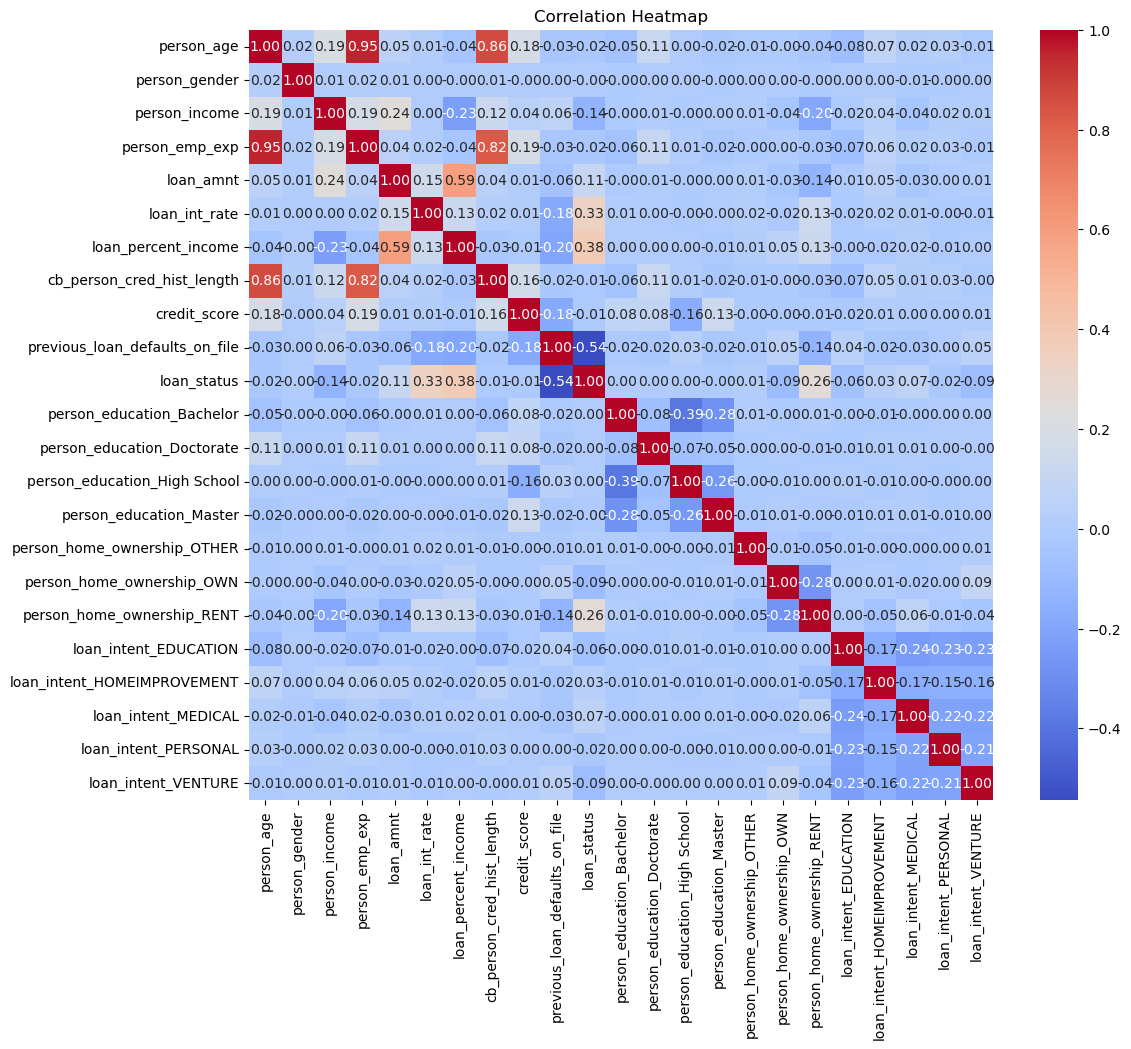

In [35]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df1=df.copy()
df1['person_gender'] = le.fit_transform(df1['person_gender'])
df1['previous_loan_defaults_on_file'] = le.fit_transform(df1['previous_loan_defaults_on_file'])
df1 = pd.get_dummies(df1, columns=['person_education', 'person_home_ownership', 'loan_intent'], drop_first=True,dtype=int)
correlation_matrix = df1.corr()
print(correlation_matrix['loan_status'].sort_values(ascending=False))
plt.figure(figsize=(12,10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()



Question: Which variables seem most correlated with loan approval? Which variables are weak predictors?

The variables that seem to be correlated the most with loan approval are the percentage of the loan vs the income and loan interest rates.
the weak ones seem to be the previous loans defaults on file and income.


# Part 2 – Building a Decision Tree Classifier


## Step 1 – Splitting the dataset


In [36]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import numpy as np

def make_data(df, cols=None, verbos=False):
    # Features & Target
    X = df.drop(columns=["loan_status"])
    if cols:
        X = X[cols]
    y = df["loan_status"]

    # Splits
    TEST_SIZE = 0.20
    VAL_SIZE = 0.20
    RANDOM_STATE = 42

    # First split off test
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
    )

    # Then split temp into train/val
    val_size_adjusted = VAL_SIZE / (1 - TEST_SIZE)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_size_adjusted, stratify=y_temp, random_state=RANDOM_STATE
    )

    if verbos:
        print(
            f"Train: {len(X_train)} ({(1-TEST_SIZE-VAL_SIZE):.0%}) | "
            f"Val: {len(X_val)} ({VAL_SIZE:.0%}) | "
            f"Test: {len(X_test)} ({TEST_SIZE:.0%})"
        )

    # Identify column types
    cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
    num_cols = X.select_dtypes(include=[np.number, "float64", "int64"]).columns.tolist()

    # Preprocessor: OneHot for categorical, passthrough for numeric
    preprocess = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
            ("num", "passthrough", num_cols),
        ]
    )
    return X_train, X_val, X_test, y_train, y_val, y_test, cat_cols, num_cols, preprocess


Question : Why do we use stratify=y in train_test_split?

We use stratify in order to keep the test data balanced between approved and rejected loans as the original dataset is unbalanced.

## Step 2 – Training a Decision Tree


In [37]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

def model_tree(preprocess, X_train, X_val, y_train, y_val, max_depth=3, criterion="gini", val=True):
    tree_clf = DecisionTreeClassifier(max_depth=max_depth, criterion=criterion, random_state=42)
    model = Pipeline(steps=[("prep", preprocess), ("tree", tree_clf)])
    model.fit(X_train, y_train)

    if val:
        y_pred = model.predict(X_val)
        print(classification_report(y_val, y_pred, digits=3))
    return model

Question: What is the difference between gini and entropy criteria in Decision Trees ? 

Gini is makes more generalities towards the majoritary class. Entropy makes more equal trees taking into account smaller classes. 

## Step 3 – Train and Evaluate


In [38]:
# Prepare splits
X_train, X_val, X_test, y_train, y_val, y_test, cat_cols, num_cols, preprocess = make_data(df, verbos=True)

# Train a simple tree
model = model_tree(preprocess, X_train, X_val, y_train, y_val, max_depth=3, val=True)


Train: 27000 (60%) | Val: 9000 (20%) | Test: 9000 (20%)
              precision    recall  f1-score   support

           0      0.904     0.968     0.935      7000
           1      0.853     0.639     0.731      2000

    accuracy                          0.895      9000
   macro avg      0.878     0.804     0.833      9000
weighted avg      0.892     0.895     0.890      9000



Question: Look at the classification report. Which metric matters most for the bank: precision (avoiding false approvals) or recall (not missing too many good customers)?

Looking at the classification report, the metrics that matters more to the bank is the recall. It has more average weight between 0.003 or 0.001 depending on the maximum depth. 

## Step 4 – Visualizing the Tree


In [39]:

import graphviz
from sklearn.tree import export_graphviz
from graphviz import Source
import os

# Recover one-hot encoded feature names
ohe = model.named_steps["prep"].named_transformers_["cat"]
ohe_names = ohe.get_feature_names_out(cat_cols)
feature_names = np.r_[ohe_names, num_cols]

# Export tree
path_file = "/Users/guillaume/Library/CloudStorage/OneDrive-DeVinci/A5/S1/Machine Learning Avancé/DAY2/TP1/tree_loan.dot"
export_graphviz(
    model.named_steps["tree"],
    out_file=path_file,
    feature_names=feature_names,
    class_names=["Rejected", "Approved"],
    rounded=True,
    filled=True,
    proportion=True,
    impurity=True
)
Source.from_file(path_file)


ExecutableNotFound: failed to execute PosixPath('dot'), make sure the Graphviz executables are on your systems' PATH

Question: Find one rule from the tree (e.g., “If income ≤ 25,000 → Reject”). What business intuition does it represent?

A simple rule from the tree is that if previous loan defaults on file are greater than 0.5, the loan is automatically rejected. It is pretty straigth forward as of a client did not repay many of his precedent loans, there is a high chance they will not repay a new one. 

Another rule is that if there are less than 0.5 previous loan defaults on file and if the loan is smaller than 0.245% of the income and if the loan interest rate is greater than 13.995, the loan will be accepted.
This represent a very strong indication that the client will repay the loan.  

# Part 3 – Interpreting the Decision Tree


## Step 1 – Feature Importance


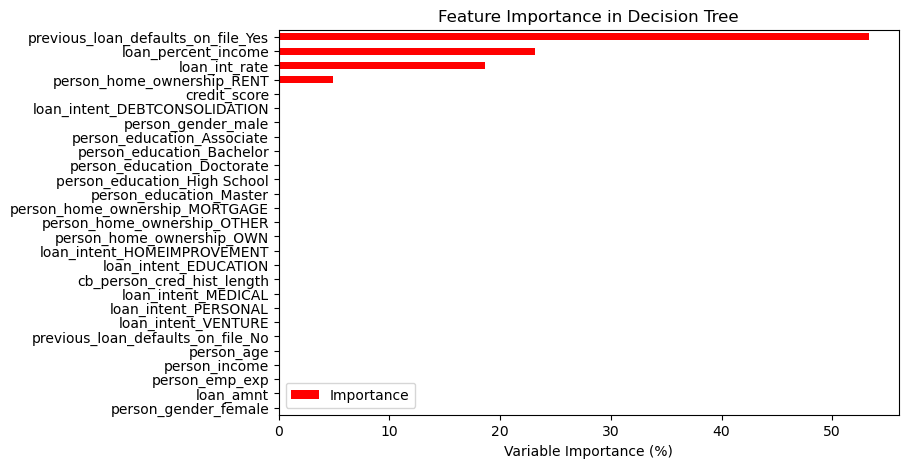

In [40]:
# Extract feature names after preprocessing
feature_names = [i[5:] for i in model.named_steps['prep'].get_feature_names_out()]

# Get feature importances from classifier
importances = model.named_steps['tree'].feature_importances_ * 100

# Build DataFrame
Importance = pd.DataFrame({'Importance': importances}, index=feature_names)

# Sort and plot
Importance.sort_values('Importance').plot(kind='barh', color='r', figsize=(8,5))
plt.xlabel('Variable Importance (%)')
plt.title("Feature Importance in Decision Tree")
plt.show()


Question: Which features are most important in predicting loan approval? Why does this make sense from a banking perspective?

The most important features in predicting loan approval are previous loan defaults on file, the percentage of the loan compared to the income, the loan's interest rate and if they are owners.
This makes sense from a banking perspective as if there are previous loan defaults on file it will lower greatly the chances of getting an approval. The comparaison between income and the percent of the loan indicates how much of their income will be left after the loan each month. The loan's interest rate is logical. And ownership indicates if they have rent AND a loan or just a loan.

## Step 2 – Focus on two features for visualization

In [41]:
cols = ["loan_int_rate", "loan_percent_income"]

X_train, X_val, X_test, y_train, y_val, y_test, cat_cols, num_cols, preprocess = make_data(df, cols=cols)

model = model_tree(preprocess, X_train, X_val, y_train, y_val,
                   max_depth=3, val=True)  # shallow tree for clear boundaries


              precision    recall  f1-score   support

           0      0.875     0.919     0.896      7000
           1      0.656     0.540     0.592      2000

    accuracy                          0.835      9000
   macro avg      0.766     0.730     0.744      9000
weighted avg      0.826     0.835     0.829      9000



## Step 3 – Decision Boundary Visualization


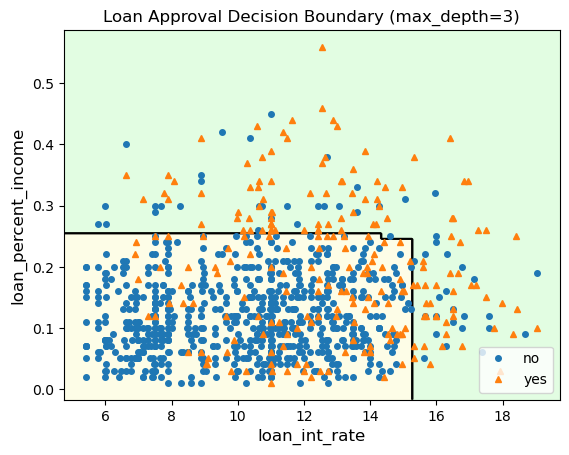

In [43]:
#from utils import plot_decision_boundary_binary
from matplotlib.colors import ListedColormap

from utils import plot_decision_boundary_binary
plot_decision_boundary_binary(
    model, X_train[:1000], y_train[:1000], feature_names=cols,
    title="Loan Approval Decision Boundary (max_depth=3)"
)
plt.show()

Question: How do the decision boundaries look? Do they match business logic?

The decision boundarie forms a box encasing every loan where the loan represents 0.25 of the income and where the interest rate is lower than 15%. The majority of the loan situated in this box are rejected.
This matches business logic as we saw with the decision tree and risk policies of the bank.
